# H-004 · Cointegration-break flat rule

Arms: `off` | `block_05_flat_10` (block new entries if ADF p≥0.05; flatten if p≥0.10 or variance jump≥2) | `flat_05` (flatten and block when ADF p≥0.05).

Type `BREAK_STAR`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    load_universe_c_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
PAIRS_STAR = list(stack["PAIRS_STAR"])
print("stack keys:", sorted(stack))
print("PAIRS_STAR", PAIRS_STAR)


stack keys: ['BAR_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR']
PAIRS_STAR ['1398.HK|0939.HK', '1288.HK|3328.HK', '8306.T|8316.T']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_c_panels(BAR, PAIRS_STAR, root=ROOT)
if stack.get("HEDGE_STAR") == "kalman":
    lb = lookbacks_for_bar(BAR)
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(train, burn_in=lb["kalman_burn_in"], z_window=lb["z_window"], hl_window=lb["hl_window"], delta=kf_delta)
    full = overlay_kalman_hedge(full, burn_in=lb["kalman_burn_in"], z_window=lb["z_window"], hl_window=lb["hl_window"], delta=kf_delta)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 10592 OOS rows 3398


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,2005-09-29,8306.T|8316.T,8306.T,8316.T,794.893020,805.781966,767.670656,789.448547,1782.033531,1879.235357,1717.232234,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-09-30,8306.T|8316.T,8306.T,8316.T,794.893202,833.004519,773.115306,811.226624,1749.632882,1798.233795,1701.031969,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-10-03,8306.T|8316.T,8306.T,8316.T,794.893317,800.337791,751.337518,773.115417,1701.032155,1733.432807,1652.431236,1717.232422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-10-04,8306.T|8316.T,8306.T,8316.T,778.559552,784.004025,751.337190,762.226135,1701.031997,1701.031997,1636.230817,1668.631348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-10-05,8306.T|8316.T,8306.T,8316.T,767.670608,784.004025,751.337190,762.226135,1636.230866,1652.431132,1594.110033,1608.690308,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach this-hyp columns


In [3]:
panel = is_panel.copy()
print(panel.columns.tolist())
panel.head()


['date', 'pair_id', 'ticker_y', 'ticker_x', 'open_y', 'high_y', 'low_y', 'close_y', 'open_x', 'high_x', 'low_x', 'close_x', 'alpha', 'beta', 'spread', 'z', 'half_life', 'adf_pvalue', 'variance_jump']


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,2005-09-29,8306.T|8316.T,8306.T,8316.T,794.893020,805.781966,767.670656,789.448547,1782.033531,1879.235357,1717.232234,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-09-30,8306.T|8316.T,8306.T,8316.T,794.893202,833.004519,773.115306,811.226624,1749.632882,1798.233795,1701.031969,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-10-03,8306.T|8316.T,8306.T,8316.T,794.893317,800.337791,751.337518,773.115417,1701.032155,1733.432807,1652.431236,1717.232422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-10-04,8306.T|8316.T,8306.T,8316.T,778.559552,784.004025,751.337190,762.226135,1701.031997,1701.031997,1636.230817,1668.631348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-10-05,8306.T|8316.T,8306.T,8316.T,767.670608,784.004025,751.337190,762.226135,1636.230866,1652.431132,1594.110033,1608.690308,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2005-09-29,2009-10-13,1050,2009-10-14,2009-10-20,2009-10-21,2013-11-13,1055
1,2,2005-09-29,2013-11-06,2105,2013-11-07,2013-11-13,2013-11-14,2017-12-08,1055
2,3,2005-09-29,2017-12-01,3160,2017-12-04,2017-12-08,2017-12-11,2021-12-31,1055


## 4. Fold-val metrics (validation only)


In [5]:
base = config_from_stack(stack)
configs = {
    "off": config_from_stack(stack, break_mode="off"),
    "block_05_flat_10": config_from_stack(stack, break_mode="block_05_flat_10"),
    "flat_05": config_from_stack(stack, break_mode="flat_05"),
}
fold_df = fold_val_metrics(panel, folds, configs, s1_weekly=s1_weekly)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,off,1,-0.455536,-0.088606,NaN,1053,38,0.890227,13.573501,13.573501
1,off,2,-1.100158,-0.172229,-0.049184,1053,53,1.000000,18.064261,18.064261
2,off,3,-0.927814,-0.144014,-0.068434,1053,53,1.000000,35.216892,35.216892
3,block_05_flat_10,1,-0.654204,-0.043336,NaN,1053,16,0.890227,13.573501,13.573501
4,block_05_flat_10,2,-0.999518,-0.063012,-0.055558,1053,18,1.000000,18.064261,18.064261
5,block_05_flat_10,3,-0.829615,-0.043814,-0.015164,1053,7,1.000000,35.216892,35.216892
6,flat_05,1,-0.749680,-0.048079,NaN,1053,20,0.890227,13.573501,13.573501
7,flat_05,2,-1.134050,-0.064921,0.005212,1053,20,1.000000,18.064261,18.064261
8,flat_05,3,-0.804262,-0.037741,-0.000484,1053,7,1.000000,35.216892,35.216892


## 5. Boxplots (do not assign STAR here)


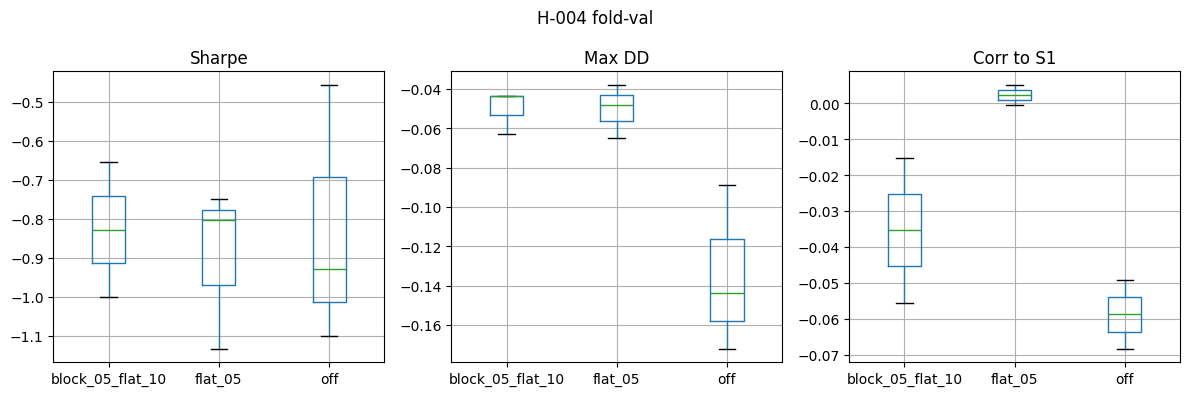

median-Sharpe hint (commentary only): flat_05


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
block_05_flat_10,-0.829615,-0.043814,-0.035361
flat_05,-0.804262,-0.048079,0.002364
off,-0.927814,-0.144014,-0.058809


In [6]:
plot_fold_boxplots(fold_df, title="H-004 fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
fold_df.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


## 6. Type `BREAK_STAR` then save


In [ ]:
BREAK_STAR = None  # TODO set after review — do not use argmax / median Sharpe
require_star("BREAK_STAR", BREAK_STAR)
stack["BREAK_STAR"] = BREAK_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH)


## 7. Sealed OOS once


In [ ]:
require_star("BREAK_STAR", BREAK_STAR)
oos_cfg = config_from_stack(load_star_stack(STAR_PATH))
oos = run_s2_backtest(oos_panel, oos_cfg, s1_weekly=s1_weekly)
print(oos.metrics)
write_tearsheet_pdf(tearsheet_path("H-004", str(BREAK_STAR)), oos.returns, title="H-004 sealed OOS")
print("tearsheet", tearsheet_path("H-004", str(BREAK_STAR)))


## 8. Notes for next hyp


H-005 spread ADX/RSI filter is next. TA-Lib required for that notebook.
